In [13]:
import subprocess, sys

packages = ['pyreadstat', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy', 'balance', 'statsmodels']
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} installed.')

In [31]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
os.makedirs('figs', exist_ok=True)

if 'src' not in sys.path:
    sys.path.insert(0, '.')

from src import config, data_loading, analysis, plotting
for mod in [config, data_loading, analysis, plotting]:
    importlib.reload(mod)

from src.config import SBP_COL, DBP_COL, PHASE2_STATE_CODES
from src.data_loading import load_nfhs5, load_nfhs4
from src.analysis import split_covid, split_nfhs4_state_matched, compute_coarse_did, get_coarse_stats
from src.plotting import (
    plot_composite_heatmap, plot_coarse_comparison_row,
    plot_coarse_did, plot_coarse_absolute_grid,
)

In [15]:
df_persons, male_2021, female_2021 = load_nfhs5('data_real/household_2021_recode/IAPR7EFL.DTA')
df_n4, male_2016, female_2016 = load_nfhs4('data_real/household_2016/IAPR74FL.DTA')

NFHS-5: 33/33 columns found
Loaded 2,843,917 person rows
Cleaned 20 zero values in 'First SYSTOLIC reading'
Cleaned 57 zero values in 'First DIASTOLIC reading'
Cleaned 7 zero values in 'Second SYSTOLIC reading'
Cleaned 40 zero values in 'Second DIASTOLIC reading'
Cleaned 12 zero values in 'Third SYSTOLIC reading'
Cleaned 37 zero values in 'Third DIASTOLIC reading'
Cleaned 1,481 implausible 'Height' (>250.0)
Cleaned 5 implausible 'Waist curcumference' (>200.0)

Total persons with BP: 1,852,899
Male: 865,780  |  Female: 987,119
Height — Male: 97,890  Female: 707,845
BMI (804,827)
Waist (805,023)
NFHS-4: 33/33 columns found
Loaded NFHS-4: 2,869,043 person-rows
NFHS-4: Cleaned 6 zero values in 'First SYSTOLIC reading'
NFHS-4: Cleaned 12 zero values in 'First DIASTOLIC reading'
NFHS-4: Cleaned 1 zero values in 'Second DIASTOLIC reading'
NFHS-4: Cleaned 1 zero values in 'Third SYSTOLIC reading'

NFHS-4 persons with BP: 811,608
Male: 111,608  |  Female: 700,000
BMI — Male: 111,316  Female: 69


NFHS-5 split: pre-COVID (Jun 2019 – March 2020) vs post-COVID (Nov 2020 – Apr 2021). 

In [41]:
nfhs5_pre_covid_male, nfhs5_post_covid_male, nfhs5_pre_covid_female, nfhs5_post_covid_female = \
    split_covid(male_2021, female_2021)

print(f"Pre-COVID  Male: {len(nfhs5_pre_covid_male):,}   Female: {len(nfhs5_pre_covid_female):,}")
print(f"Post-COVID Male: {len(nfhs5_post_covid_male):,}   Female: {len(nfhs5_post_covid_female):,}")



Pre-COVID  Male: 604,314   Female: 682,567
Post-COVID Male: 261,458   Female: 304,545


In [42]:

all_n5 = pd.concat([male_2021, female_2021])
year = all_n5['Year of interview']
month = all_n5['Month of interview']

pre_mask  = (year == 2019) | ((year == 2020) & (month <= 3))
post_mask = ((year == 2020) & (month >= 11)) | (year == 2021)

state_phase = []
for sc in sorted(all_n5['State code'].dropna().unique()):
    sub = all_n5[all_n5['State code'] == sc]
    n_pre  = pre_mask[sub.index].sum()
    n_post = post_mask[sub.index].sum()
    n_gap  = len(sub) - n_pre - n_post
    total  = len(sub)
    pct_pre  = 100 * n_pre / total if total > 0 else 0
    pct_post = 100 * n_post / total if total > 0 else 0
    
    if n_post == 0:
        phase = "Phase1-only"
    elif n_pre == 0:
        phase = "Phase2-only"
    elif pct_post >= 50:
        phase = "Mostly-Phase2"
    elif pct_pre >= 50:
        phase = "Mostly-Phase1"
    else:
        phase = "Mixed"
    
    state_phase.append({
        'State code': int(sc), 'n_total': total,
        'n_pre': n_pre, 'n_post': n_post, 'n_gap': n_gap,
        'pct_pre': round(pct_pre, 1), 'pct_post': round(pct_post, 1),
        'classification': phase
    })

sp_df = pd.DataFrame(state_phase)
print("STATE CLASSIFICATION FROM ACTUAL NFHS-5 DATA")
print("=" * 90)
print(sp_df.to_string(index=False))

#Derive correct Phase 2 = states that are predominantly post-COVID
correct_phase2 = set(sp_df[sp_df['classification'].isin(['Phase2-only', 'Mostly-Phase2'])]['State code'])
correct_phase1_only = set(sp_df[sp_df['classification'] == 'Phase1-only']['State code'])
overlap_states = set(sp_df[sp_df['classification'].str.startswith('Mostly')]['State code'])

print(f"\n{'─'*90}")
print(f"Phase 1 ONLY states (pre-COVID only):       {sorted(correct_phase1_only)}")
print(f"Phase 2 ONLY states (post-COVID only):       {sorted(set(sp_df[sp_df['classification']=='Phase2-only']['State code']))}")
print(f"Overlap states (in both, classified by majority): {sorted(overlap_states)}")


#Verify coverage
pre_f_correct  = nfhs5_pre_covid_female[~nfhs5_pre_covid_female['State code'].isin(correct_phase2)]
post_f_correct = nfhs5_post_covid_female[nfhs5_post_covid_female['State code'].isin(correct_phase2)]
print(f"  Pre-COVID female in Phase 1 states:  {len(pre_f_correct):,} / {len(nfhs5_pre_covid_female):,} ({100*len(pre_f_correct)/len(nfhs5_pre_covid_female):.1f}%)")
print(f"  Post-COVID female in Phase 2 states: {len(post_f_correct):,} / {len(nfhs5_post_covid_female):,} ({100*len(post_f_correct)/len(nfhs5_post_covid_female):.1f}%)")

STATE CLASSIFICATION FROM ACTUAL NFHS-5 DATA
 State code  n_total  n_pre  n_post  n_gap  pct_pre  pct_post classification
          1    59568  59568       0      0    100.0       0.0    Phase1-only
          2    29435  29435       0      0    100.0       0.0    Phase1-only
          3    55896  26357   29539      0     47.2      52.8  Mostly-Phase2
          4     1564      0    1564      0      0.0     100.0    Phase2-only
          5    31777  13798   17979      0     43.4      56.6  Mostly-Phase2
          6    55636  17000   38636      0     30.6      69.4  Mostly-Phase2
          7    24209  12716   11493      0     52.5      47.5  Mostly-Phase1
          8   107444  81715   25729      0     76.1      23.9  Mostly-Phase1
          9   222288  85291  136988      9     38.4      61.6  Mostly-Phase2
         10    99999  99999       0      0    100.0       0.0    Phase1-only
         11     8557   8557       0      0    100.0       0.0    Phase1-only
         12    50144  19485   3

In [43]:
#NFHS-4 year split
for df_sex in [male_2016, female_2016]:
    df_sex.dropna(subset=['Year of interview'], inplace=True)

female_2015  = female_2016[female_2016['Year of interview'] == 2015]
female_2016y = female_2016[female_2016['Year of interview'] == 2016]
male_2015    = male_2016[male_2016['Year of interview'] == 2015]
male_2016y   = male_2016[male_2016['Year of interview'] == 2016]

# NFHS-5 year subsets 
male_2019    = male_2021[male_2021['Year of interview'] == 2019]
male_2020    = male_2021[male_2021['Year of interview'] == 2020]
male_2021y   = male_2021[male_2021['Year of interview'] == 2021]
female_2019  = female_2021[female_2021['Year of interview'] == 2019]
female_2020  = female_2021[female_2021['Year of interview'] == 2020]
female_2021y = female_2021[female_2021['Year of interview'] == 2021]

# Post-COVID year subsets 
female_post2020 = nfhs5_post_covid_female[nfhs5_post_covid_female['Year of interview'] == 2020]
female_post2021 = nfhs5_post_covid_female[nfhs5_post_covid_female['Year of interview'] == 2021]

print(f"NFHS-4: 2015 M={len(male_2015):,} F={len(female_2015):,} | 2016 M={len(male_2016y):,} F={len(female_2016y):,}")
print(f"NFHS-5: 2019 M={len(male_2019):,} F={len(female_2019):,} | 2020 M={len(male_2020):,} F={len(female_2020):,} | 2021 M={len(male_2021y):,} F={len(female_2021y):,}")
print(f"Post-COVID year: 2020 F={len(female_post2020):,} | 2021 F={len(female_post2021):,}")

NFHS-4: 2015 M=53,901 F=355,304 | 2016 M=57,707 F=344,696
NFHS-5: 2019 M=413,206 F=464,551 | 2020 M=254,263 F=286,373 | 2021 M=198,311 F=236,195
Post-COVID year: 2020 F=68,350 | 2021 F=236,195


Saved figs\Figure_1.png


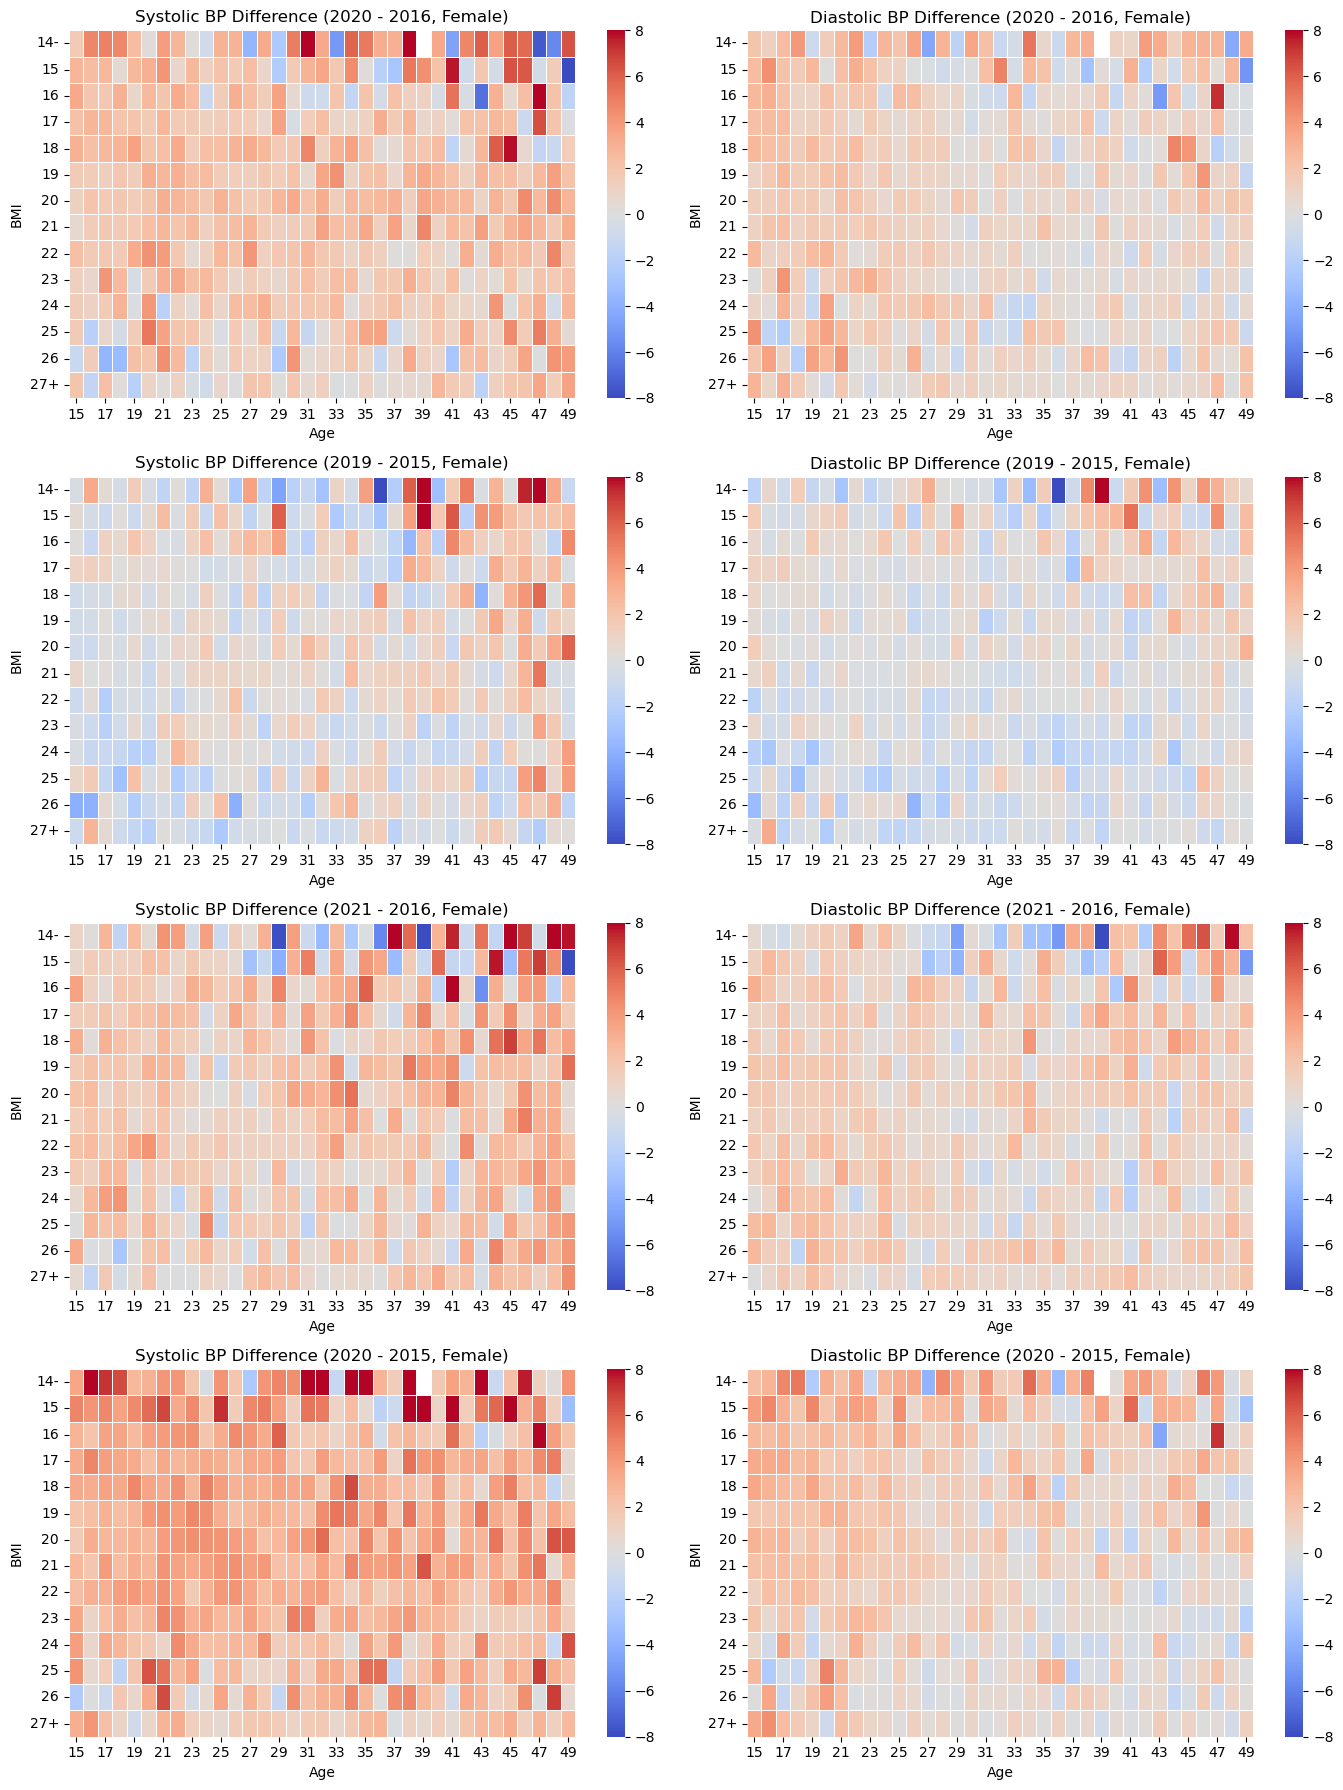

In [44]:

plot_composite_heatmap([
    (female_2016y, female_2020,  '2020 - 2016, Female'),
    (female_2015,  female_2019,  '2019 - 2015, Female'),
    (female_2016y, female_2021y, '2021 - 2016, Female'),
    (female_2015,  female_2020,  '2020 - 2015, Female'),
], 'Figure 1', 'Figure_1')

Saved figs\Figure_2.png


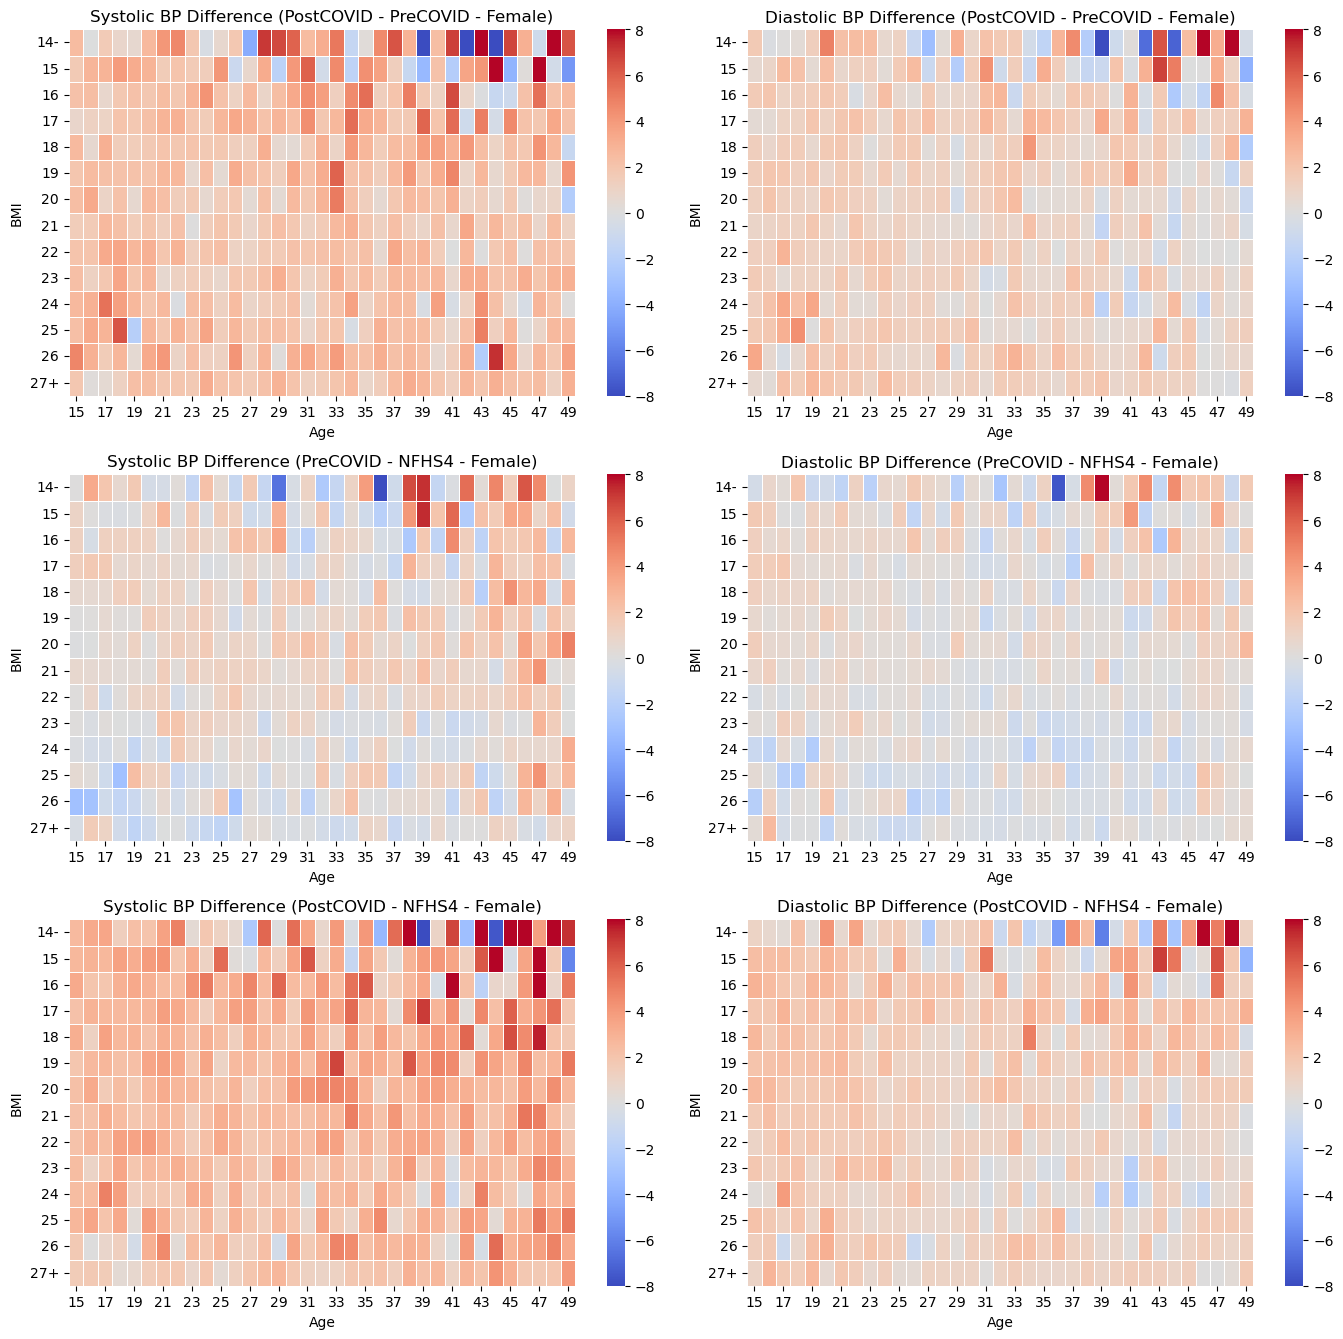

In [45]:

plot_composite_heatmap([
    (nfhs5_pre_covid_female, nfhs5_post_covid_female, 'PostCOVID - PreCOVID - Female'),
    (female_2016, nfhs5_pre_covid_female,             'PreCOVID - NFHS4 - Female'),
    (female_2016, nfhs5_post_covid_female,            'PostCOVID - NFHS4 - Female'),
], 'Figure 2', 'Figure_2')

In [46]:

nfhs4_pre_eq_male, nfhs4_post_eq_male, nfhs4_pre_eq_female, nfhs4_post_eq_female = \
    split_nfhs4_state_matched(male_2016, female_2016)

print(f"NFHS-4 Pre-eq  (Phase 1 states) — Male: {len(nfhs4_pre_eq_male):,}   Female: {len(nfhs4_pre_eq_female):,}")
print(f"NFHS-4 Post-eq (Phase 2 states) — Male: {len(nfhs4_post_eq_male):,}   Female: {len(nfhs4_post_eq_female):,}")

NFHS-4 Pre-eq  (Phase 1 states) — Male: 71,634   Female: 424,488
NFHS-4 Post-eq (Phase 2 states) — Male: 39,974   Female: 275,512


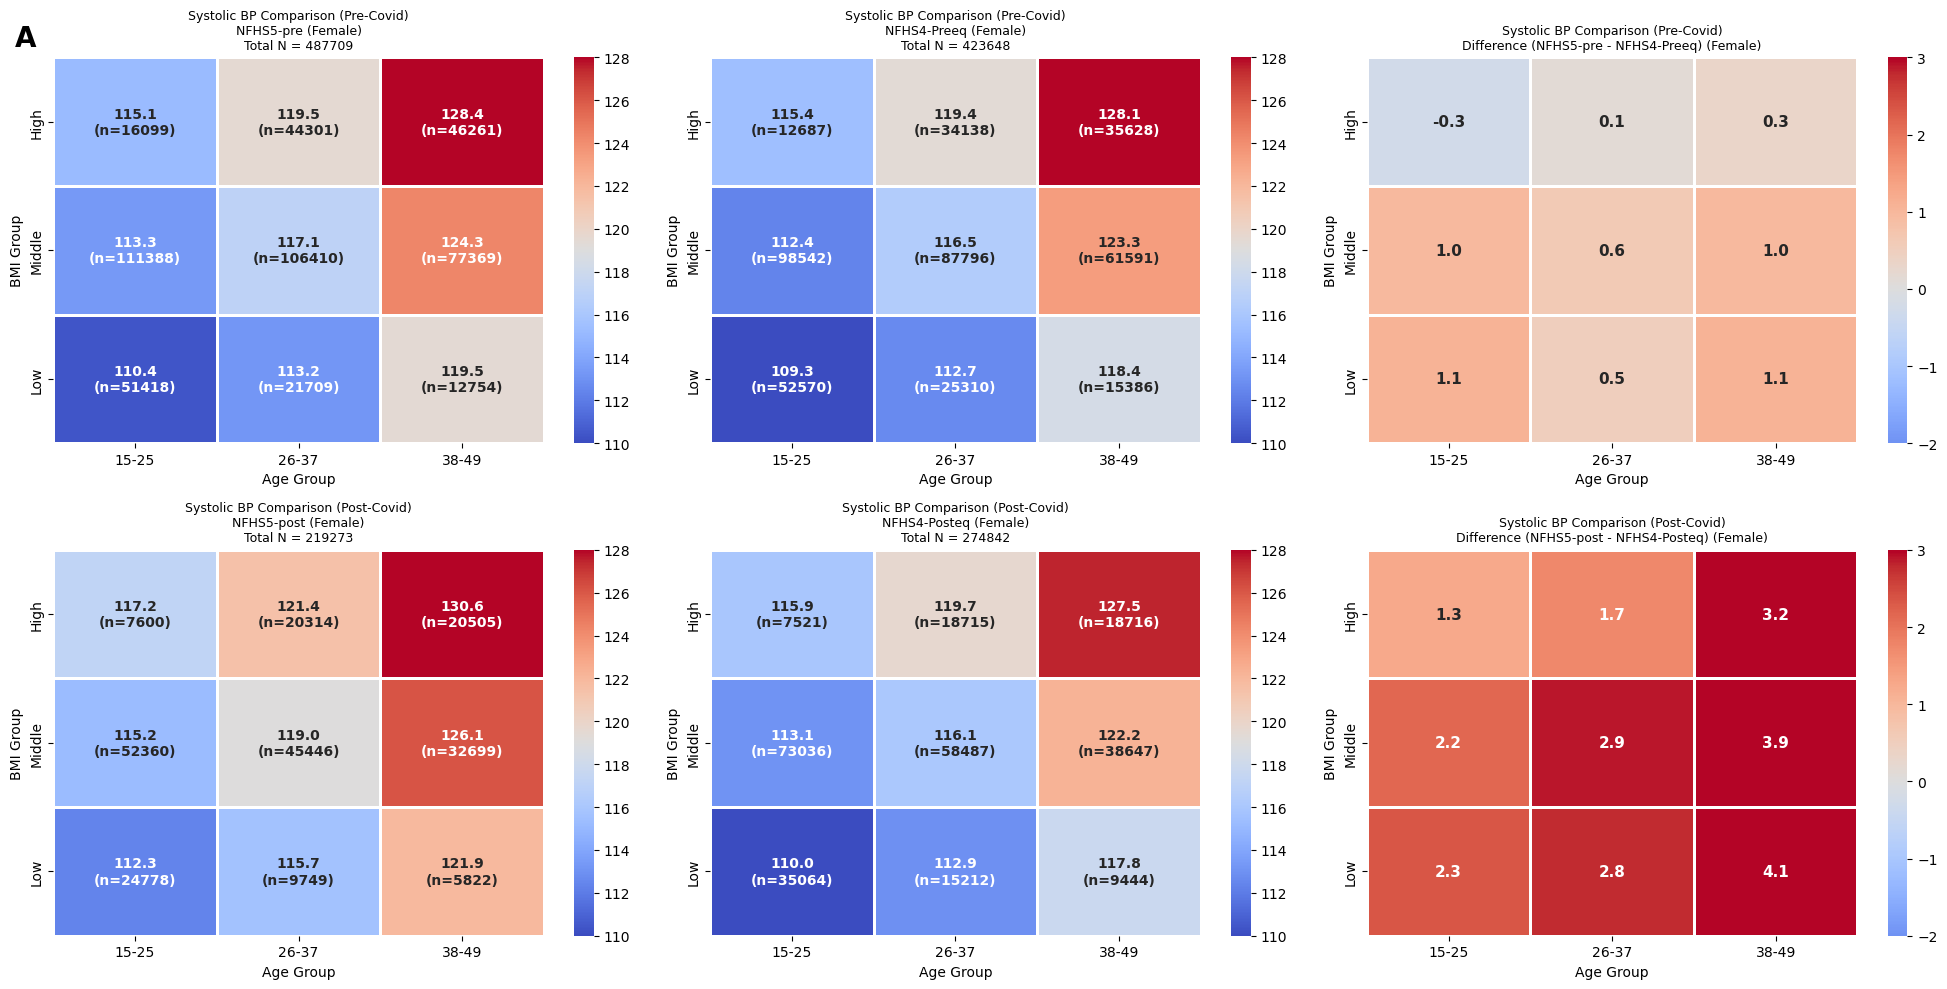

In [47]:

fig, axes = plt.subplots(2, 3, figsize=(20, 10))


plot_coarse_comparison_row(axes[0], nfhs5_pre_covid_female, nfhs4_pre_eq_female,
    SBP_COL, 'NFHS5-pre', 'NFHS4-Preeq', 'Female', 'Pre-Covid',
    bp_label='Systolic', abs_vmin=110, abs_vmax=128, diff_vmin=-2, diff_vmax=3)


plot_coarse_comparison_row(axes[1], nfhs5_post_covid_female, nfhs4_post_eq_female,
    SBP_COL, 'NFHS5-post', 'NFHS4-Posteq', 'Female', 'Post-Covid',
    bp_label='Systolic', abs_vmin=110, abs_vmax=128, diff_vmin=-2, diff_vmax=3)

fig.text(0.01, 0.97, 'A', fontsize=20, fontweight='bold', va='top')
plt.tight_layout()
fig.savefig('figs/Figure_3A.png', dpi=300, bbox_inches='tight')
plt.show()

Saved figs\Figure_3B.png


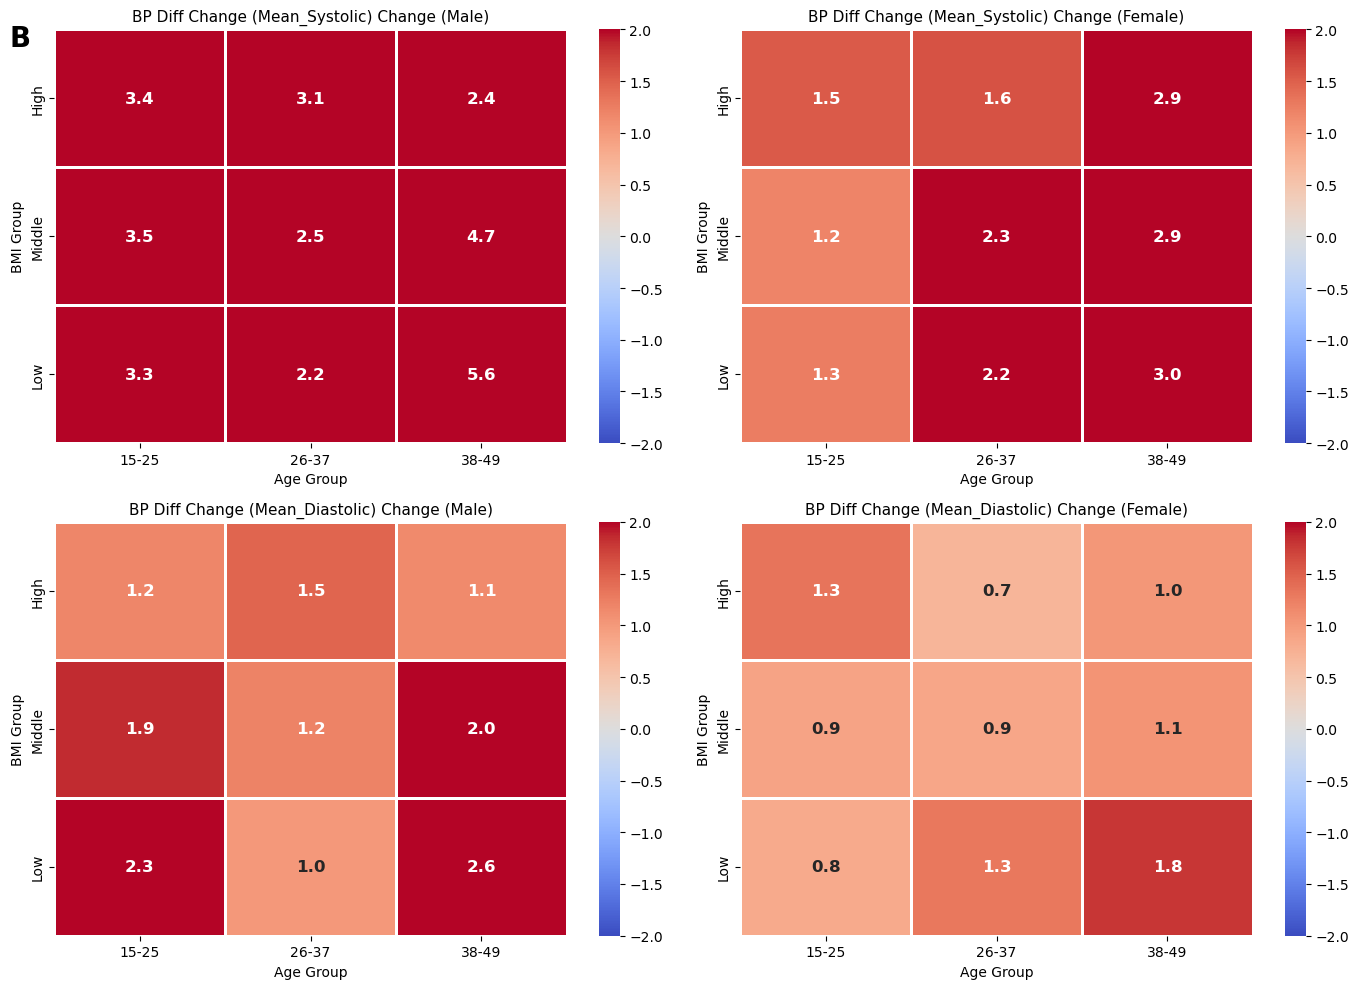

In [48]:

plot_coarse_did([
    ('Male',   nfhs5_pre_covid_male,   nfhs5_post_covid_male,   nfhs4_pre_eq_male,   nfhs4_post_eq_male),
    ('Female', nfhs5_pre_covid_female, nfhs5_post_covid_female, nfhs4_pre_eq_female, nfhs4_post_eq_female),
], 'Figure_3B')

Saved figs\Figure_S1.png


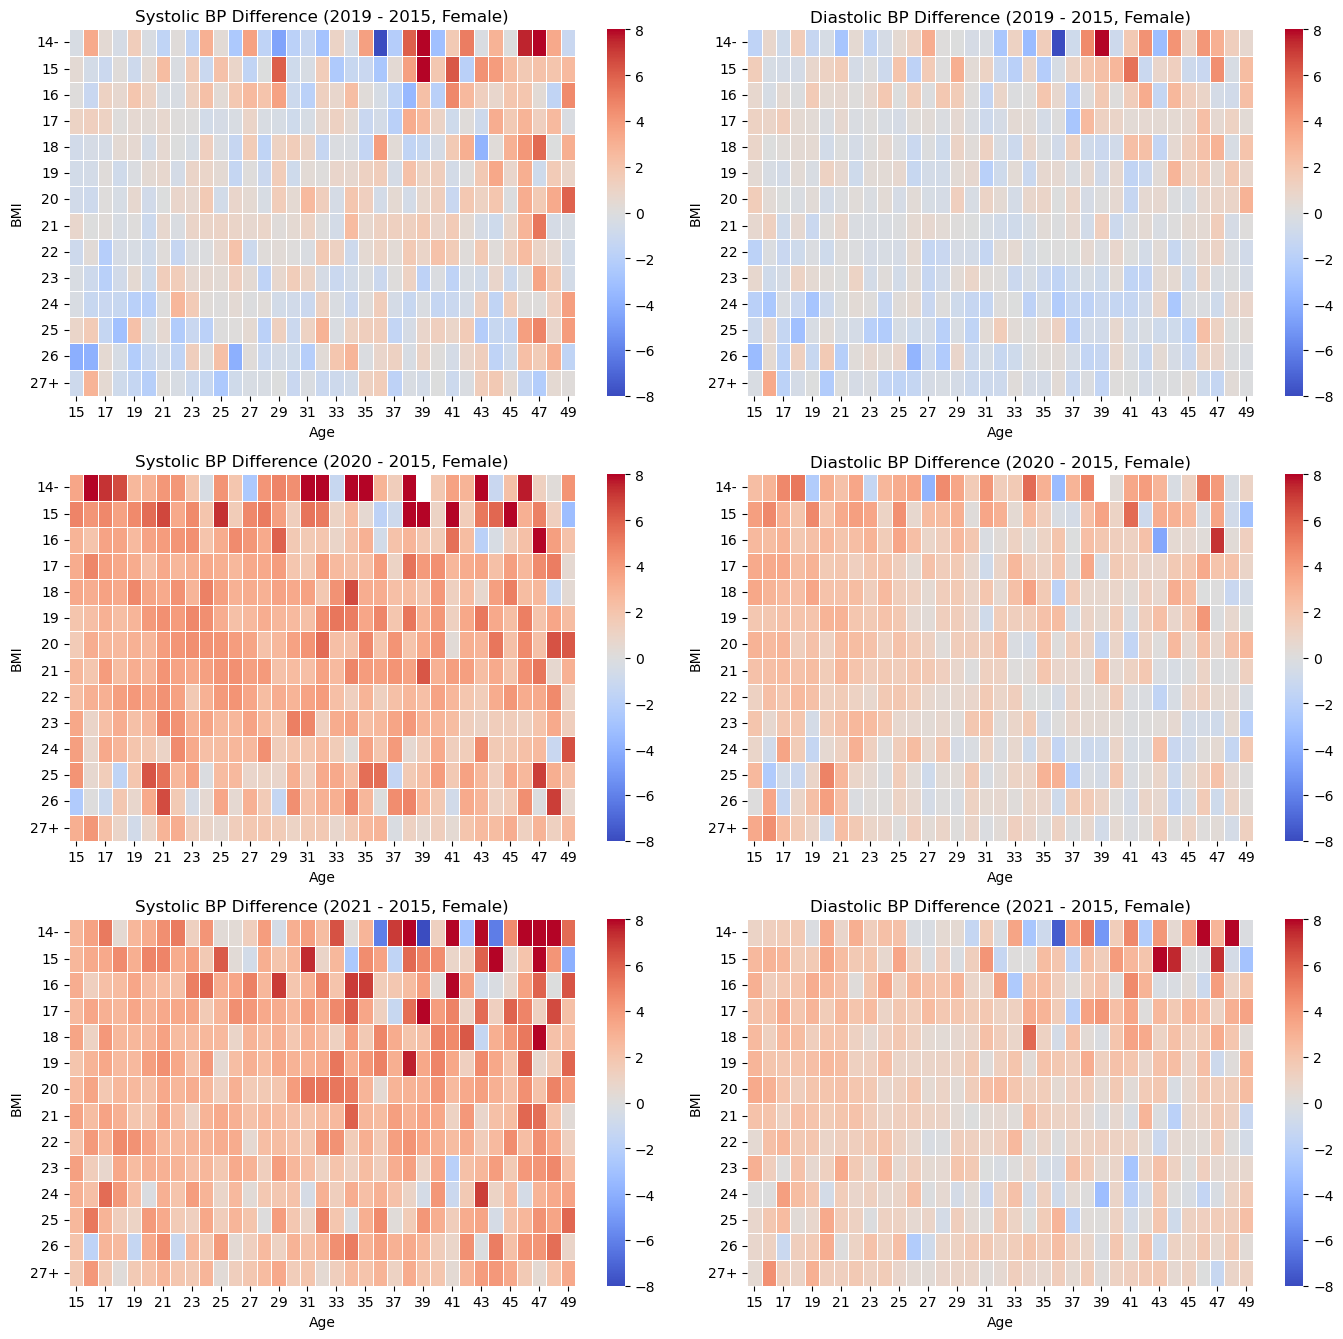

Saved figs\Figure_S2.png


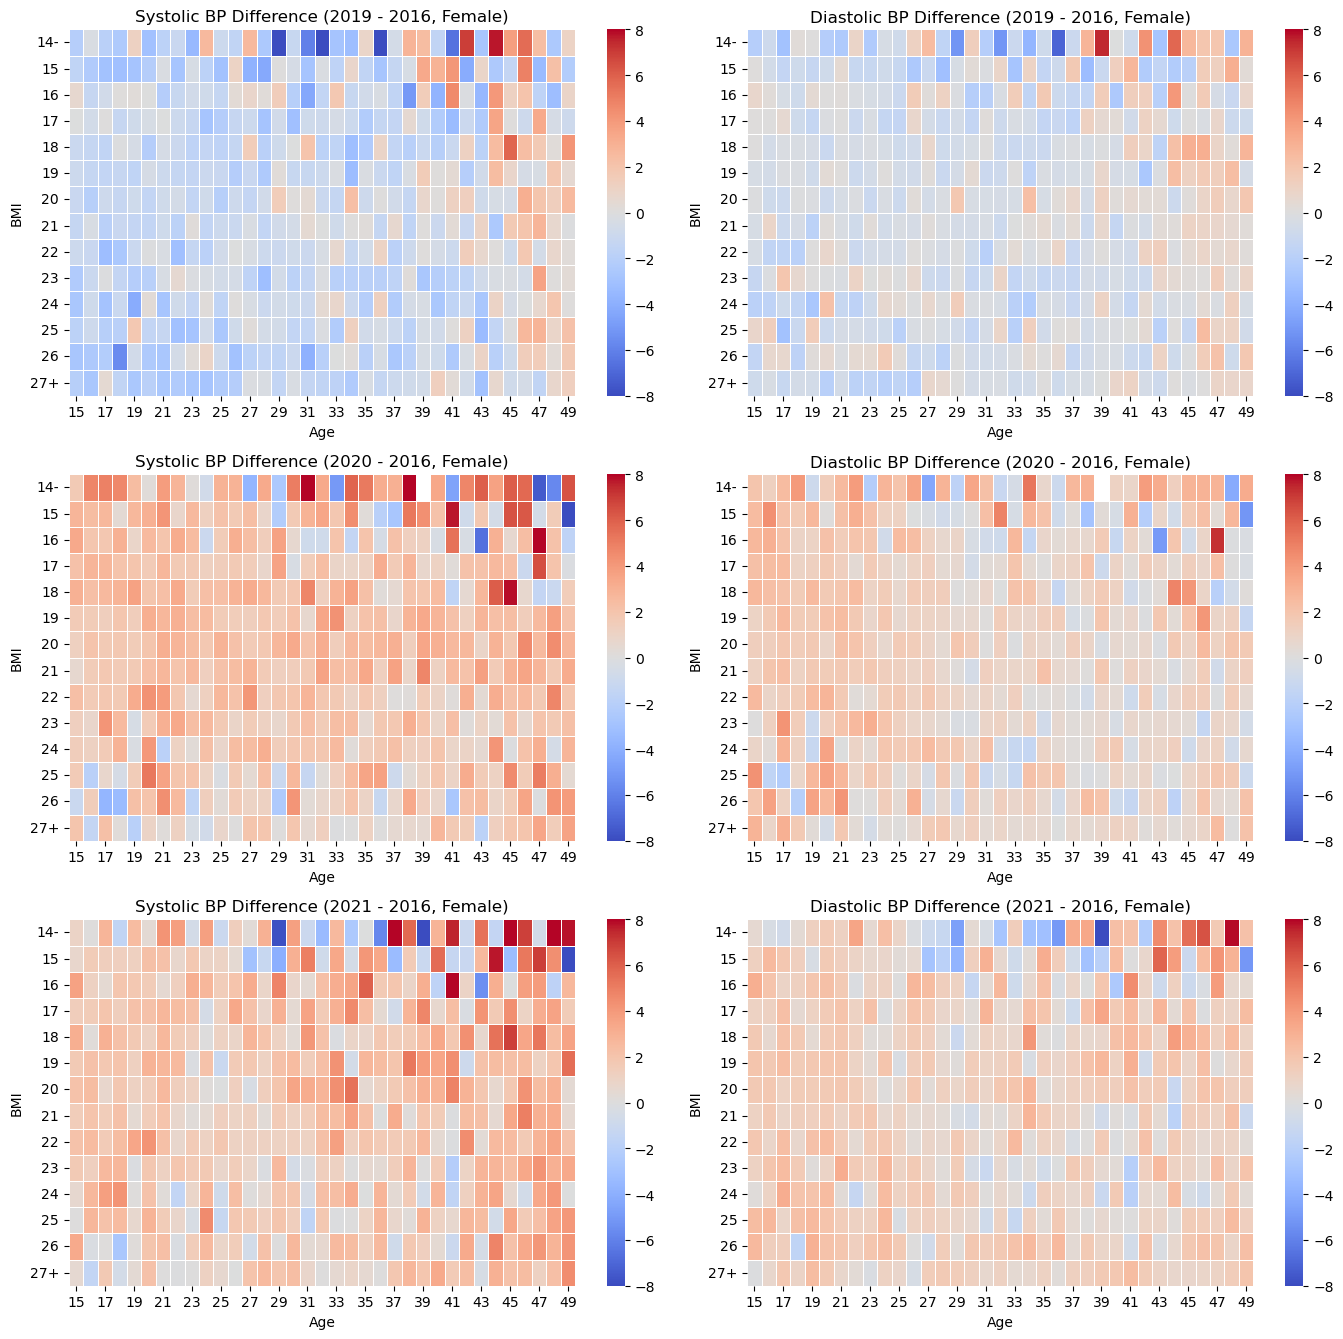

In [49]:

plot_composite_heatmap([
    (female_2015, female_2019,  '2019 - 2015, Female'),
    (female_2015, female_2020,  '2020 - 2015, Female'),
    (female_2015, female_2021y, '2021 - 2015, Female'),
], 'Figure S1', 'Figure_S1')


plot_composite_heatmap([
    (female_2016y, female_2019,  '2019 - 2016, Female'),
    (female_2016y, female_2020,  '2020 - 2016, Female'),
    (female_2016y, female_2021y, '2021 - 2016, Female'),
], 'Figure S2', 'Figure_S2')

Saved figs\Figure_S3.png


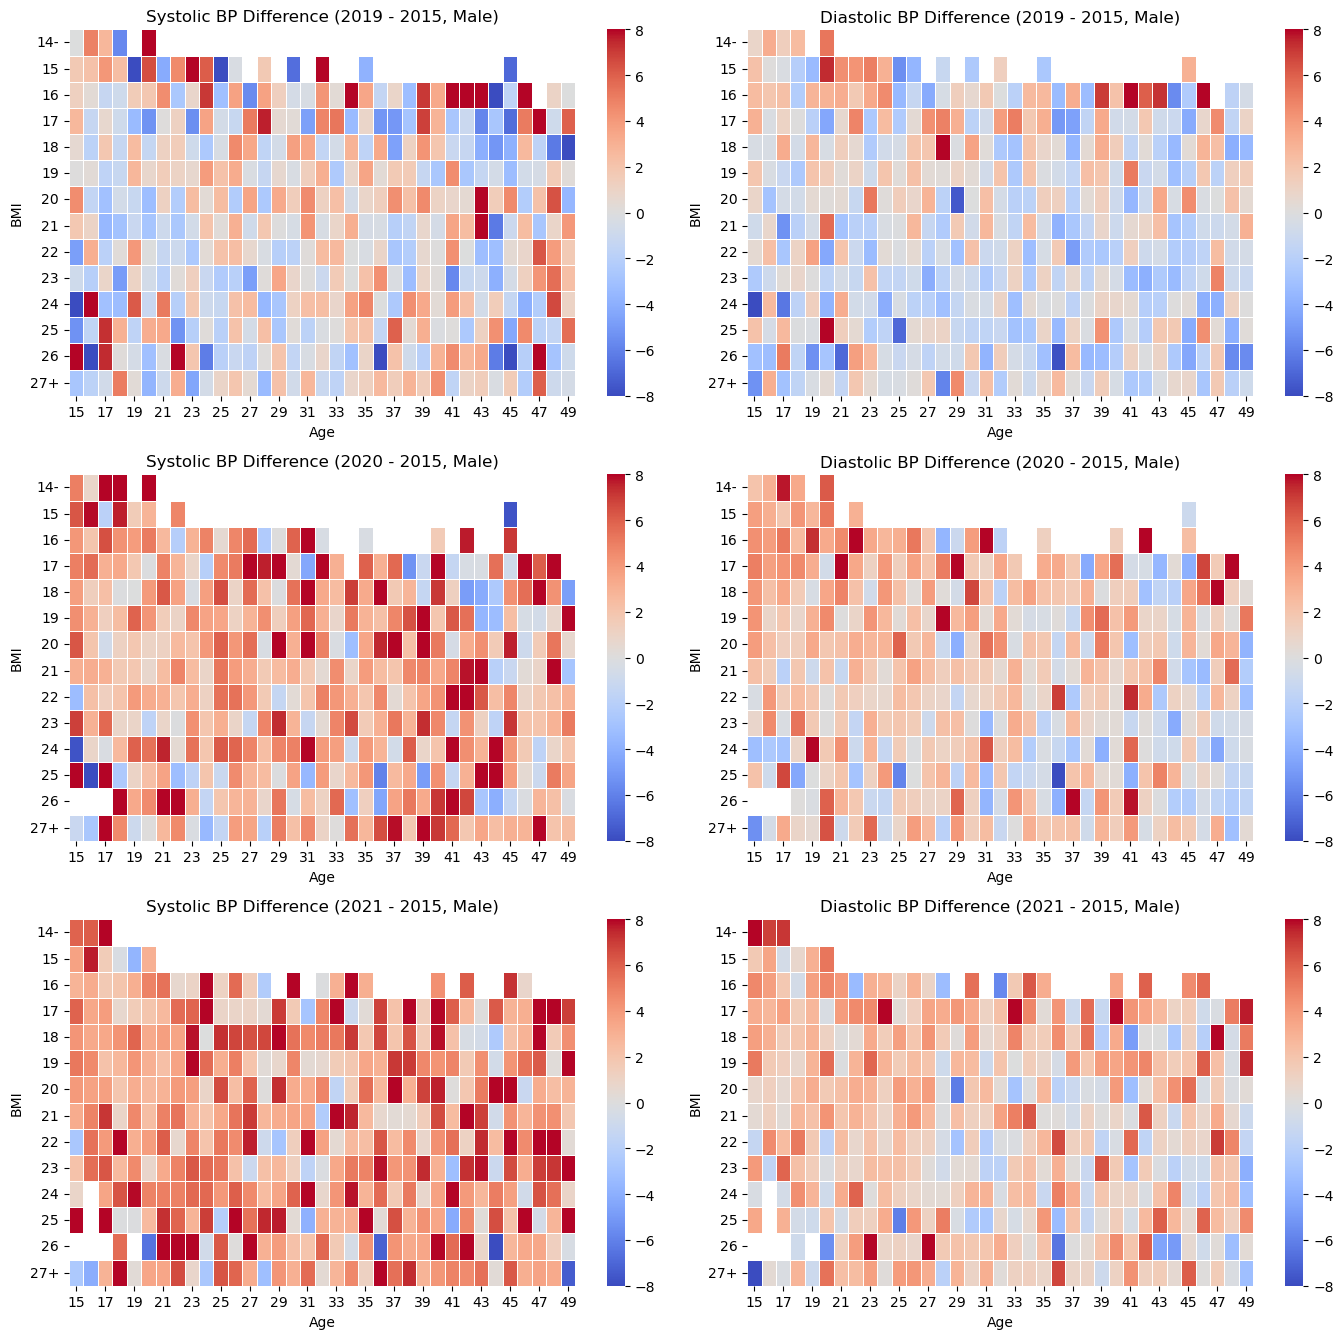

Saved figs\Figure_S4.png


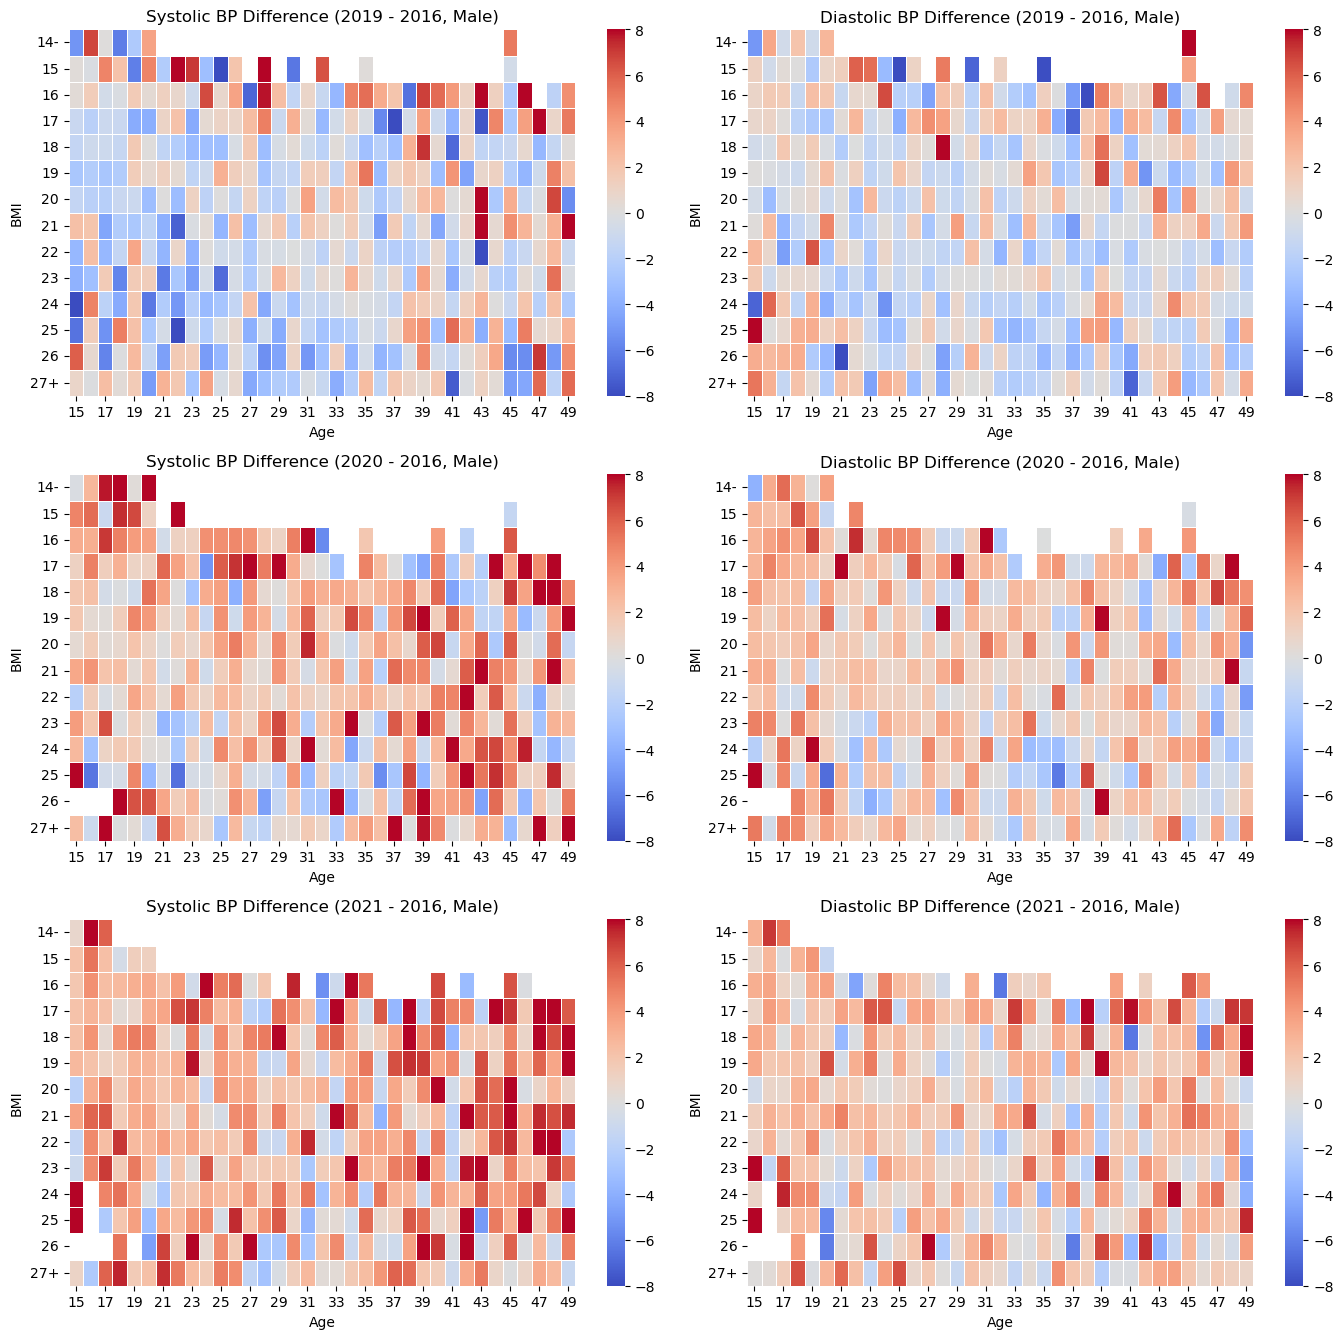

In [50]:

plot_composite_heatmap([
    (male_2015, male_2019,  '2019 - 2015, Male'),
    (male_2015, male_2020,  '2020 - 2015, Male'),
    (male_2015, male_2021y, '2021 - 2015, Male'),
], 'Figure S3', 'Figure_S3')


plot_composite_heatmap([
    (male_2016y, male_2019,  '2019 - 2016, Male'),
    (male_2016y, male_2020,  '2020 - 2016, Male'),
    (male_2016y, male_2021y, '2021 - 2016, Male'),
], 'Figure S4', 'Figure_S4')

Saved figs\Figure_S5.png


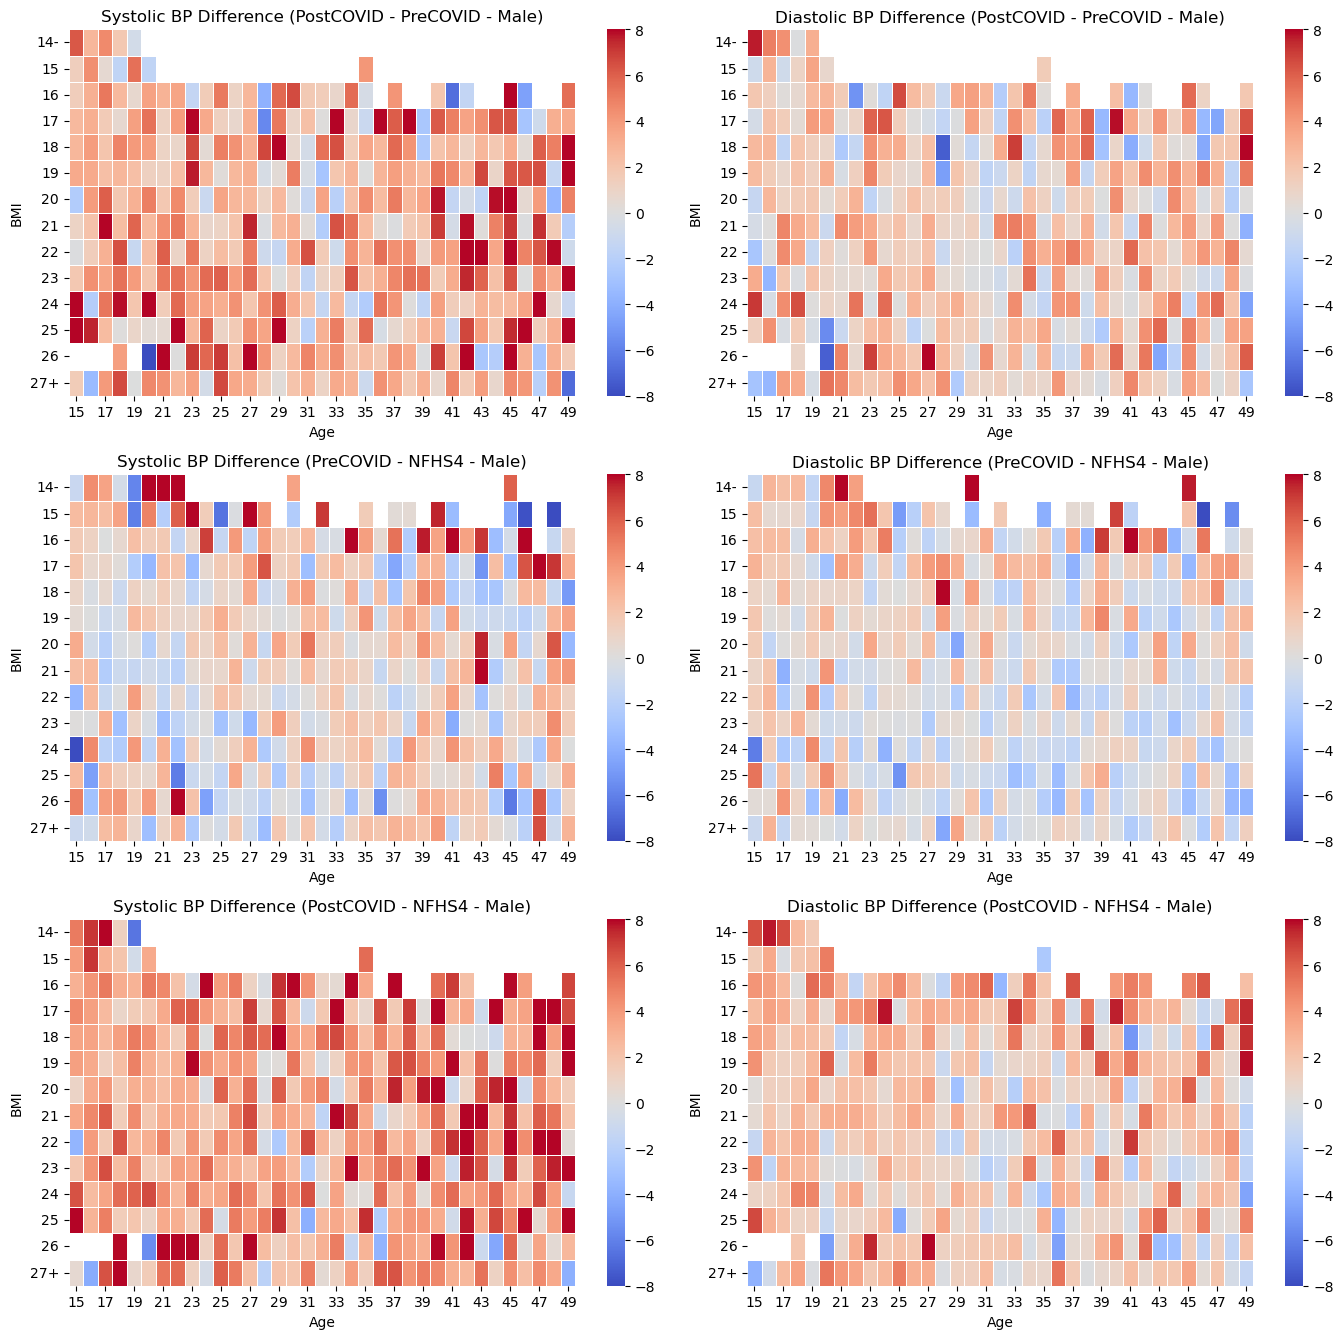

In [51]:

plot_composite_heatmap([
    (nfhs5_pre_covid_male, nfhs5_post_covid_male, 'PostCOVID - PreCOVID - Male'),
    (male_2016, nfhs5_pre_covid_male,             'PreCOVID - NFHS4 - Male'),
    (male_2016, nfhs5_post_covid_male,            'PostCOVID - NFHS4 - Male'),
], 'Figure S5', 'Figure_S5')

Saved figs\Figure_S6.png


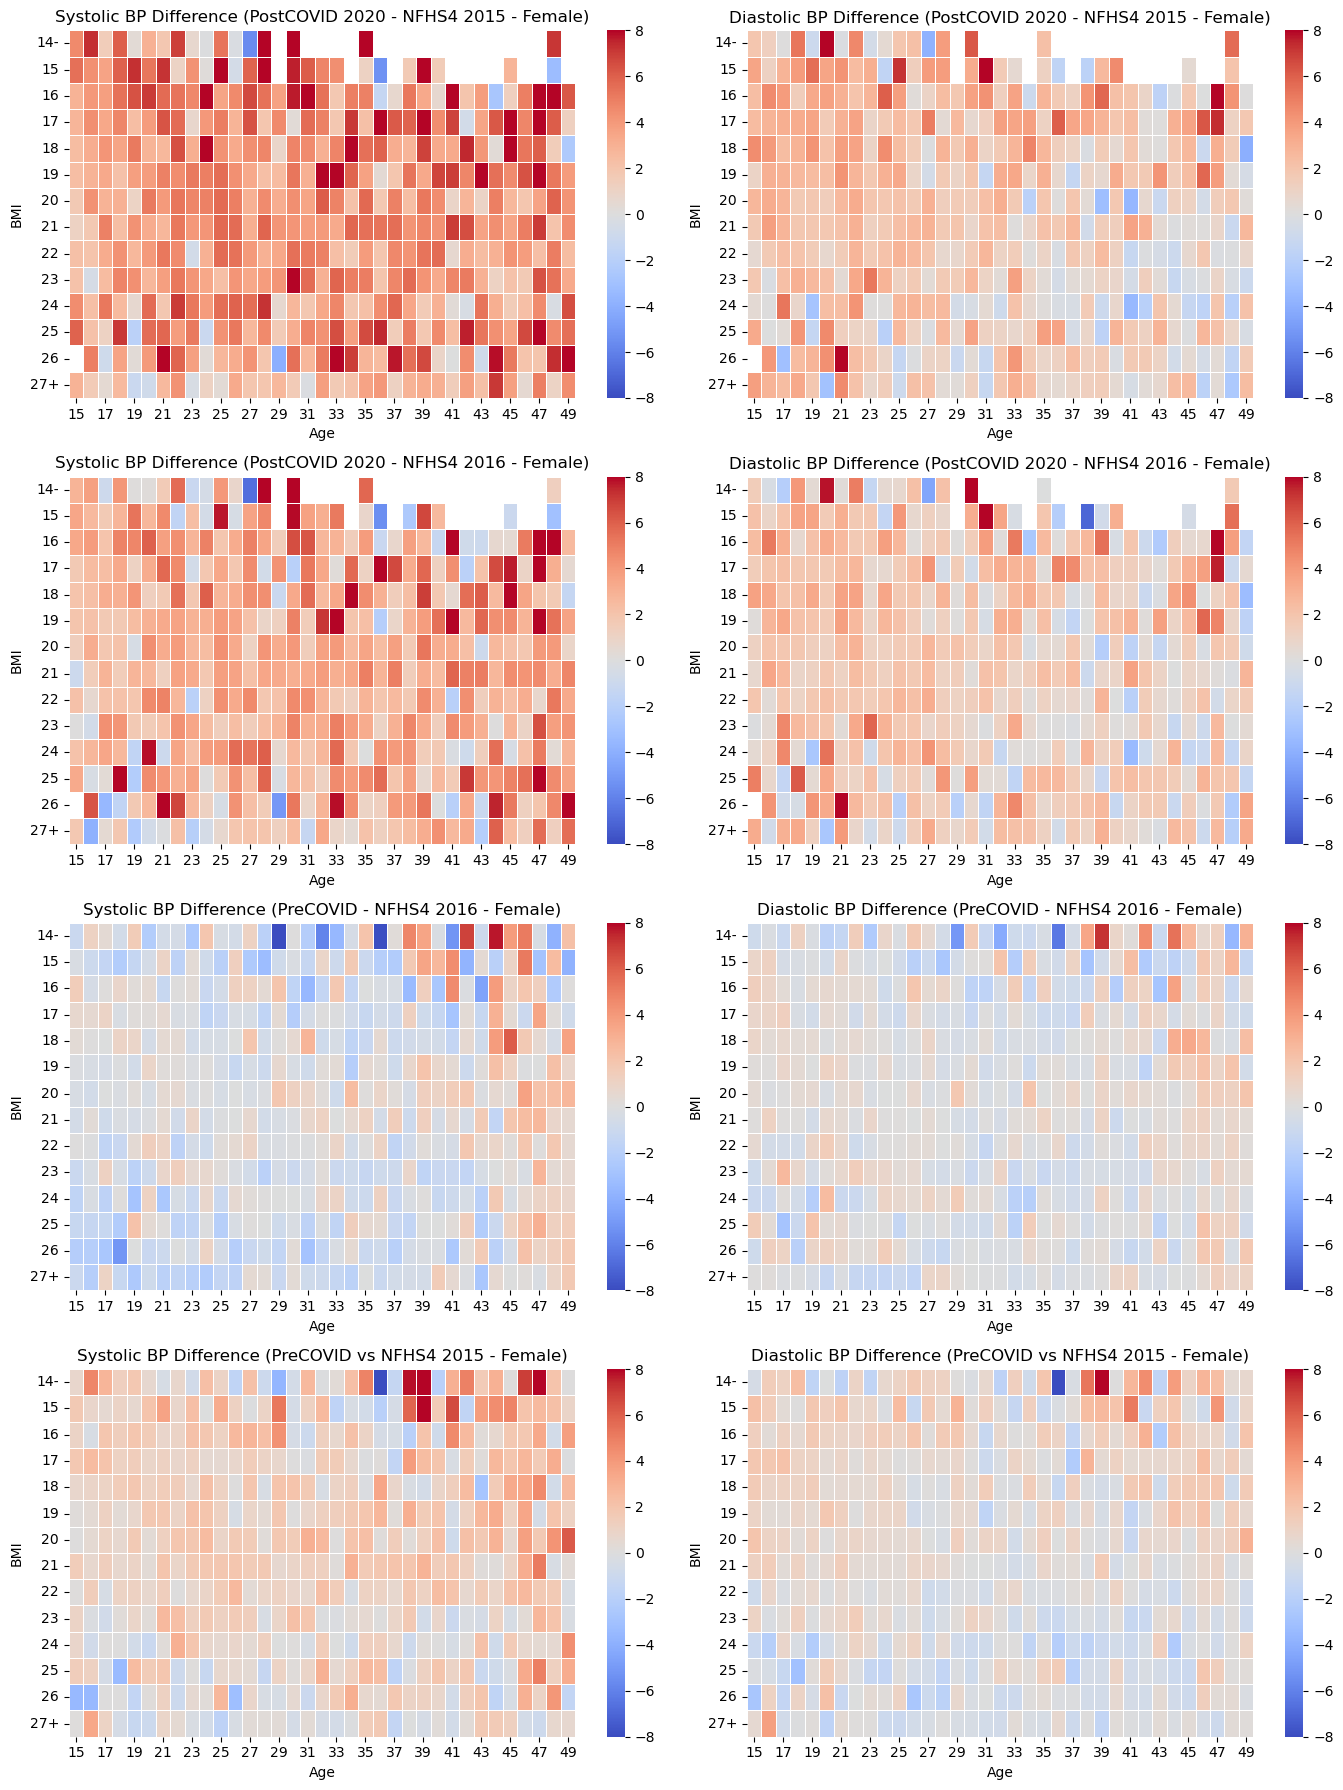

Saved figs\Figure_S7.png


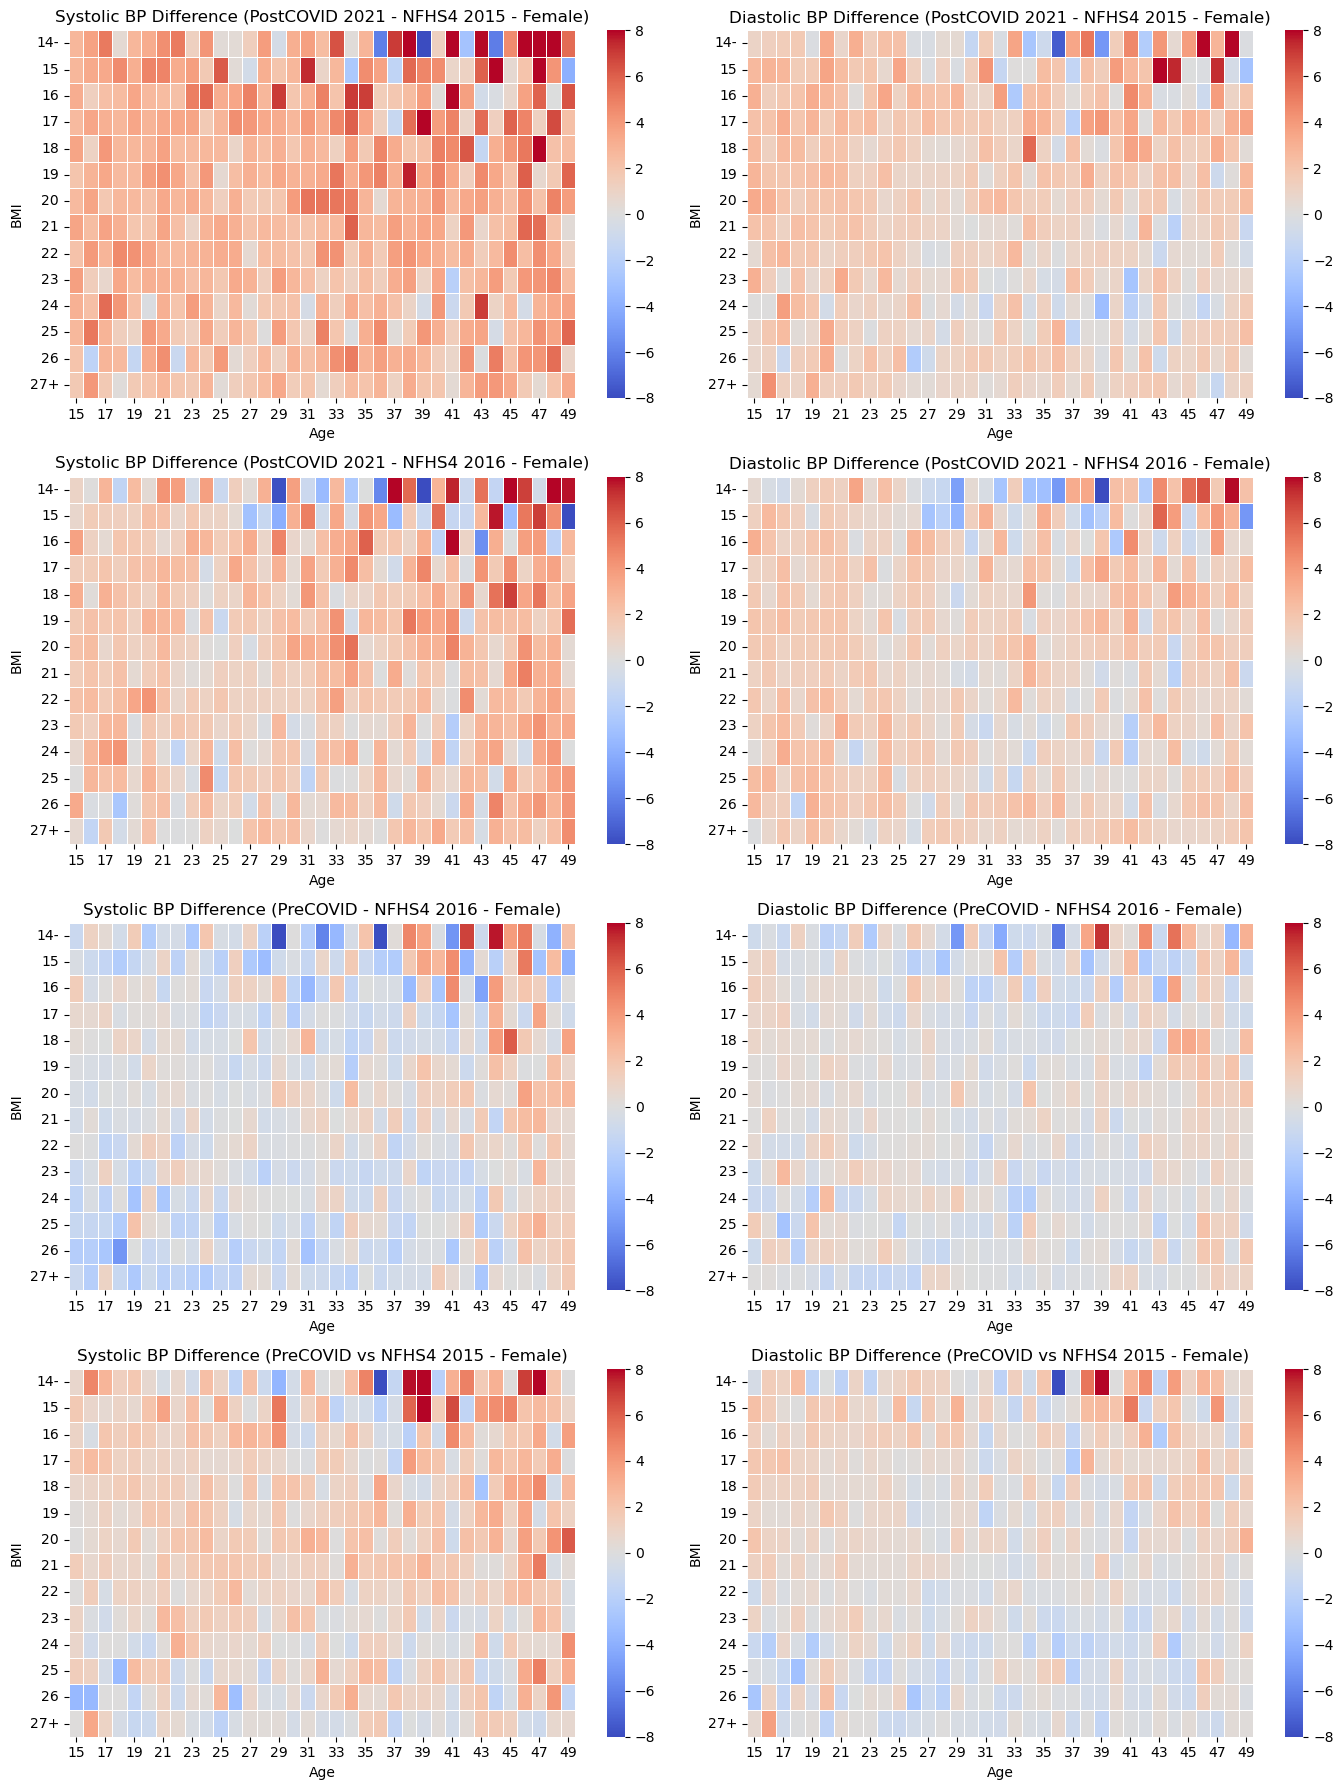

In [52]:

plot_composite_heatmap([
    (female_2015,  female_post2020,          'PostCOVID 2020 - NFHS4 2015 - Female'),
    (female_2016y, female_post2020,          'PostCOVID 2020 - NFHS4 2016 - Female'),
    (female_2016y, nfhs5_pre_covid_female,   'PreCOVID - NFHS4 2016 - Female'),
    (female_2015,  nfhs5_pre_covid_female,   'PreCOVID vs NFHS4 2015 - Female'),
], 'Figure S6', 'Figure_S6')

plot_composite_heatmap([
    (female_2015,  female_post2021,          'PostCOVID 2021 - NFHS4 2015 - Female'),
    (female_2016y, female_post2021,          'PostCOVID 2021 - NFHS4 2016 - Female'),
    (female_2016y, nfhs5_pre_covid_female,   'PreCOVID - NFHS4 2016 - Female'),
    (female_2015,  nfhs5_pre_covid_female,   'PreCOVID vs NFHS4 2015 - Female'),
], 'Figure S7', 'Figure_S7')

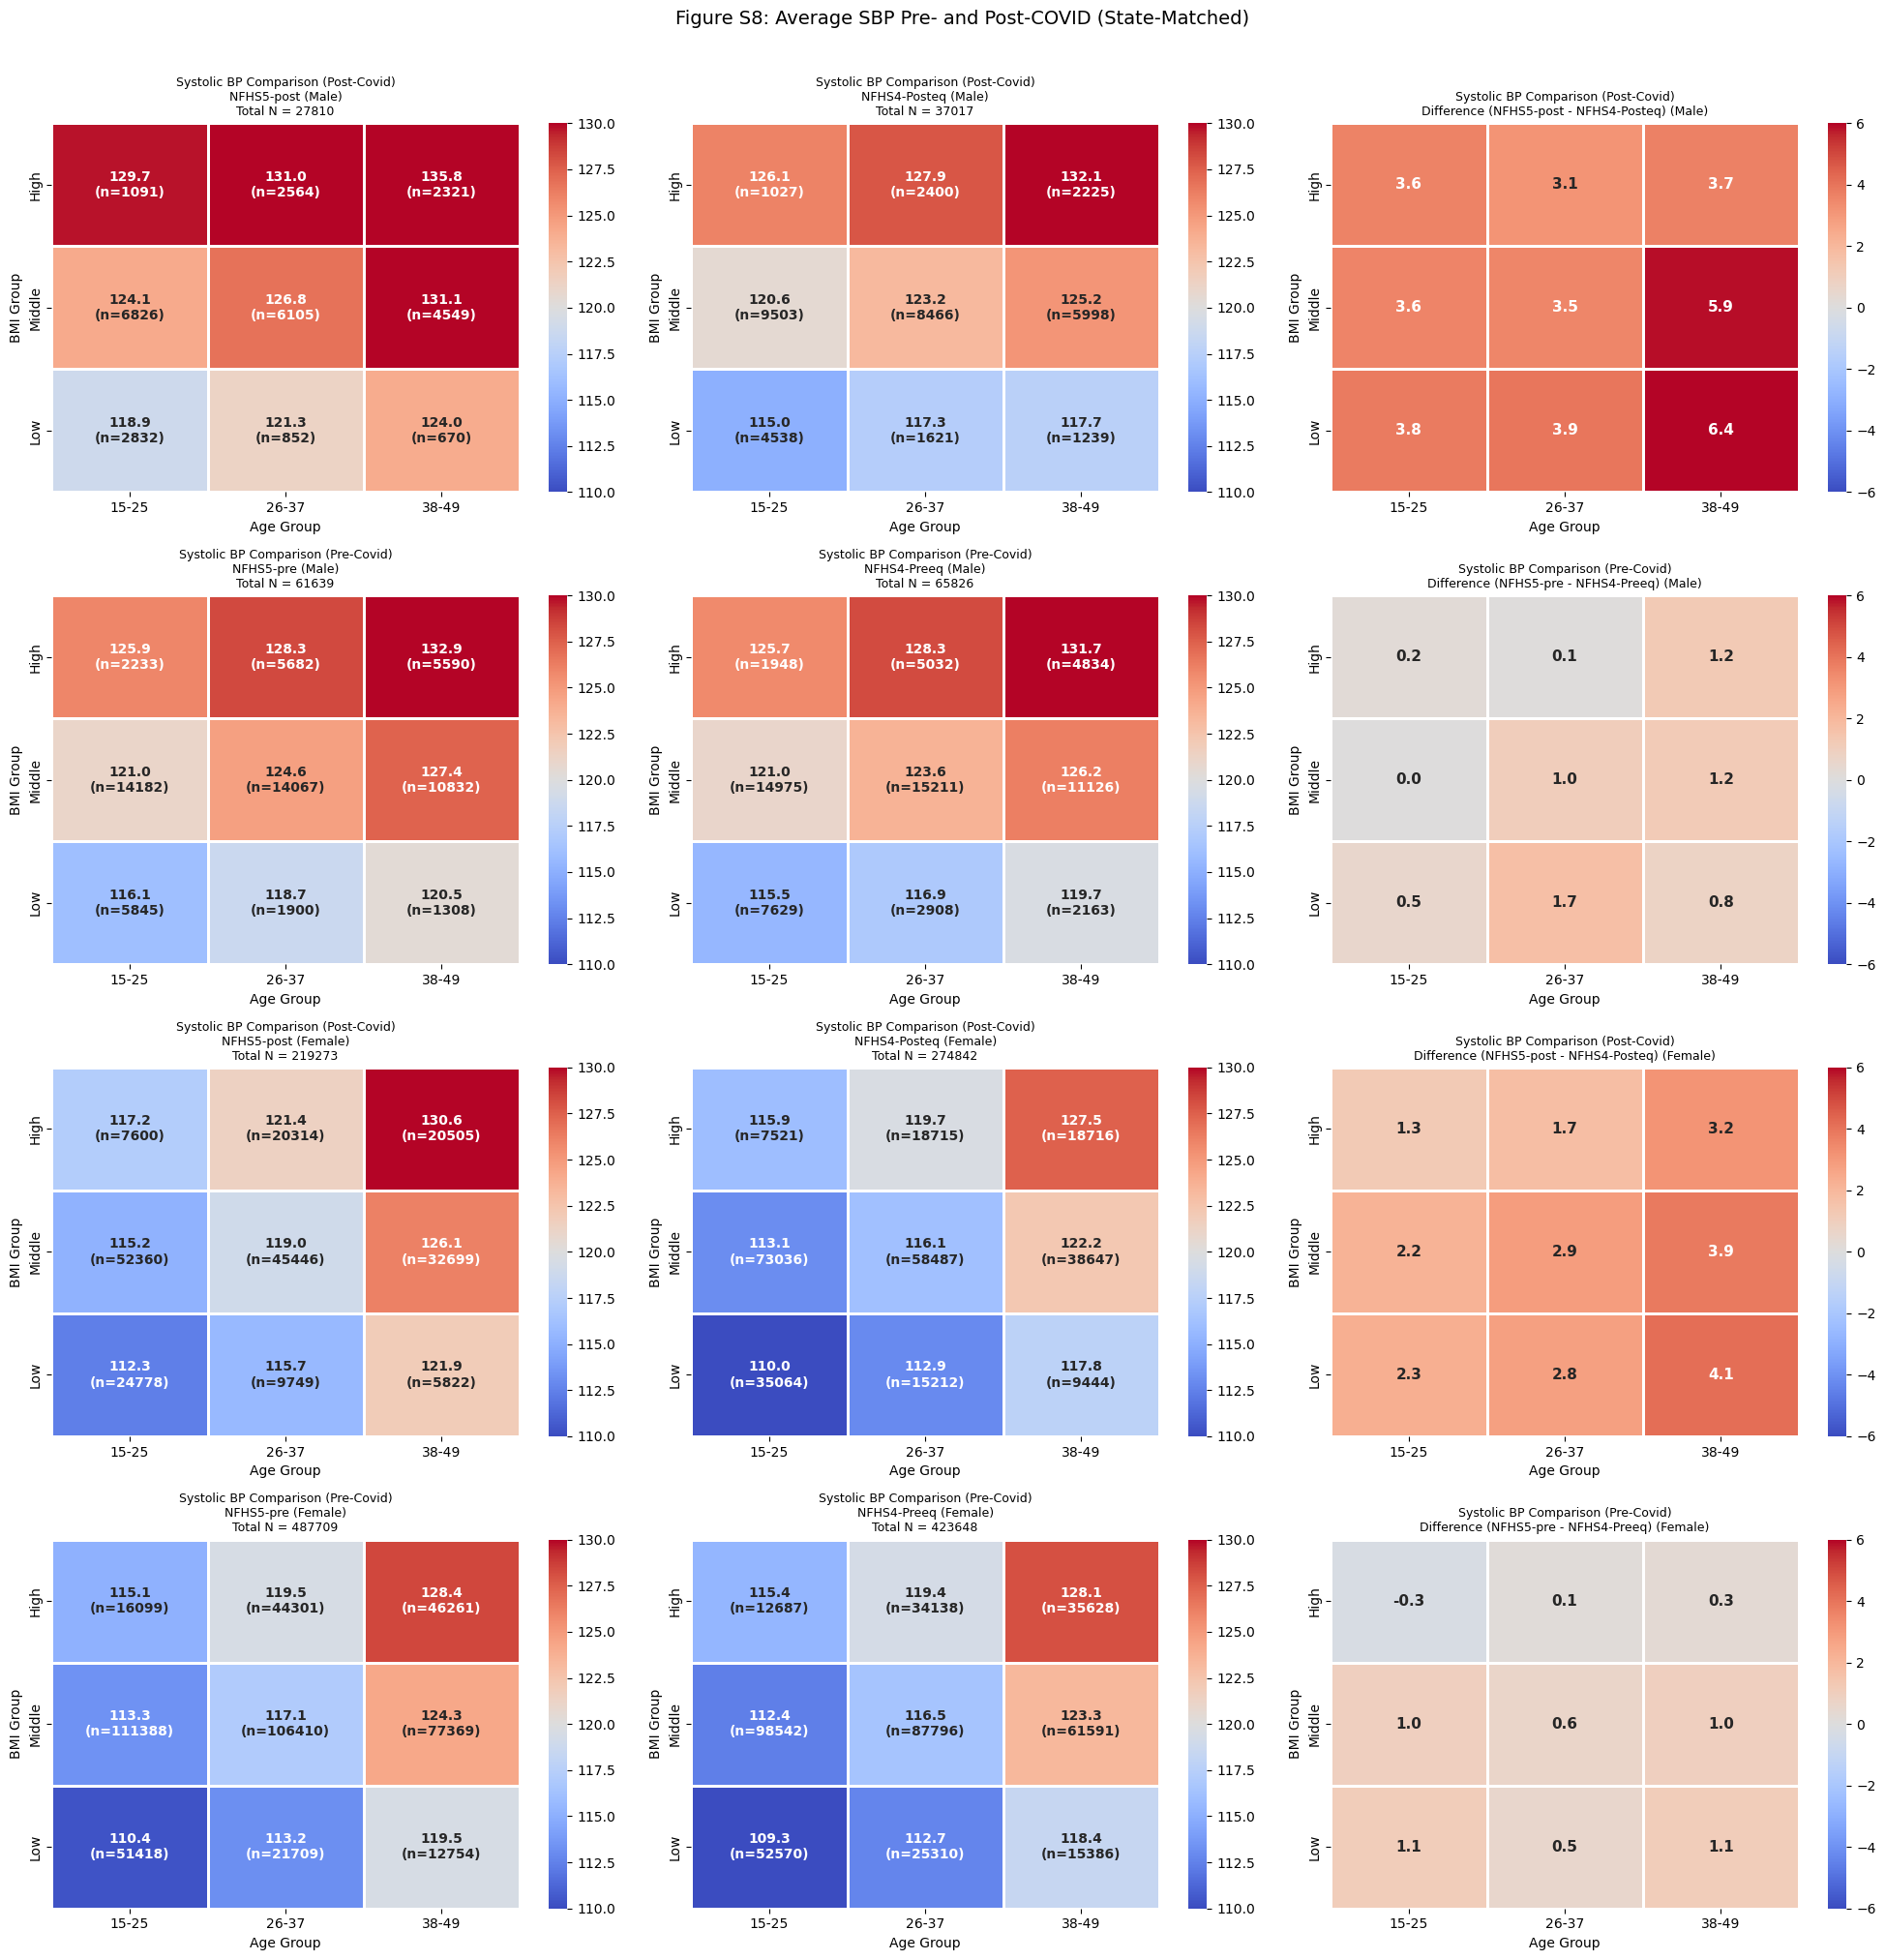

In [53]:

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

rows_s8 = [
    (nfhs5_post_covid_male,   nfhs4_post_eq_male,   'NFHS5-post', 'NFHS4-Posteq', 'Male',   'Post-Covid'),
    (nfhs5_pre_covid_male,    nfhs4_pre_eq_male,    'NFHS5-pre',  'NFHS4-Preeq',  'Male',   'Pre-Covid'),
    (nfhs5_post_covid_female, nfhs4_post_eq_female, 'NFHS5-post', 'NFHS4-Posteq', 'Female', 'Post-Covid'),
    (nfhs5_pre_covid_female,  nfhs4_pre_eq_female,  'NFHS5-pre',  'NFHS4-Preeq',  'Female', 'Pre-Covid'),
]
for i, (n5, n4, lbl_n5, lbl_n4, gender, period) in enumerate(rows_s8):
    plot_coarse_comparison_row(axes[i], n5, n4, SBP_COL, lbl_n5, lbl_n4, gender, period,
                               bp_label='Systolic', abs_vmin=110, abs_vmax=130, diff_vmin=-6, diff_vmax=6)

plt.suptitle('Figure S8: Average SBP Pre- and Post-COVID (State-Matched)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('figs/Figure_S8.png', dpi=300, bbox_inches='tight')
plt.show()

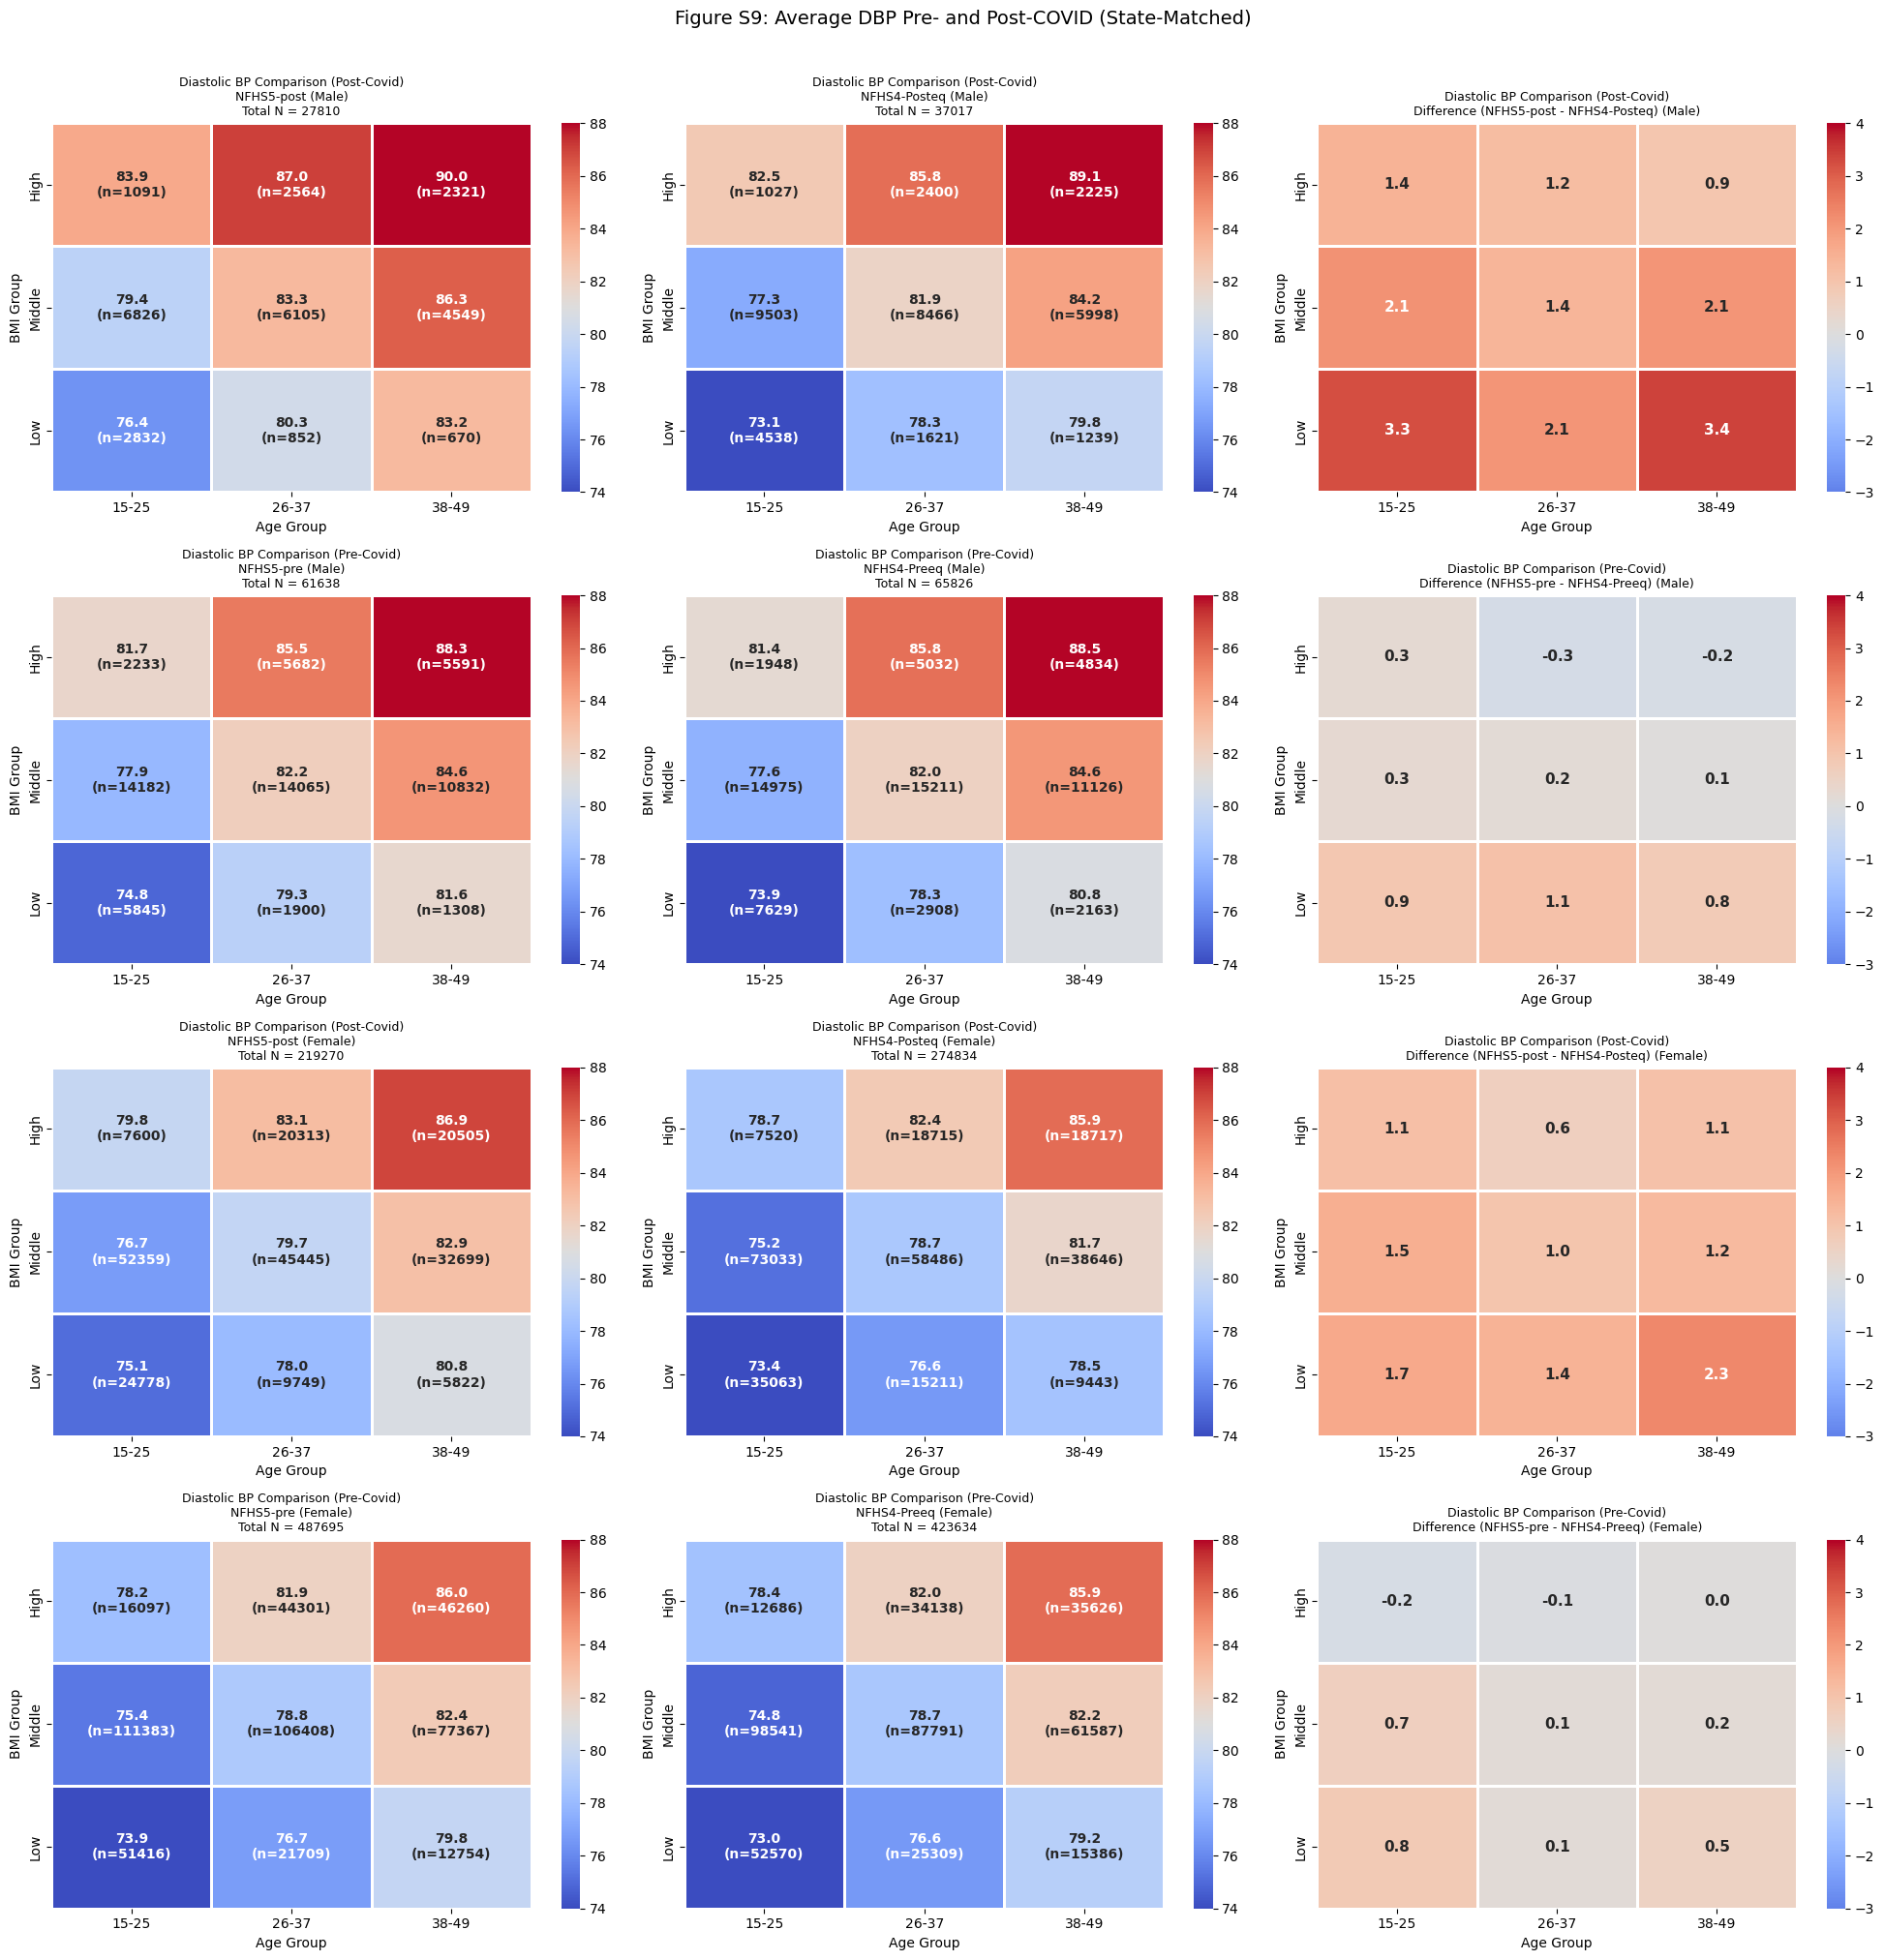

In [54]:

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

rows_s9 = [
    (nfhs5_post_covid_male,   nfhs4_post_eq_male,   'NFHS5-post', 'NFHS4-Posteq', 'Male',   'Post-Covid'),
    (nfhs5_pre_covid_male,    nfhs4_pre_eq_male,    'NFHS5-pre',  'NFHS4-Preeq',  'Male',   'Pre-Covid'),
    (nfhs5_post_covid_female, nfhs4_post_eq_female, 'NFHS5-post', 'NFHS4-Posteq', 'Female', 'Post-Covid'),
    (nfhs5_pre_covid_female,  nfhs4_pre_eq_female,  'NFHS5-pre',  'NFHS4-Preeq',  'Female', 'Pre-Covid'),
]
for i, (n5, n4, lbl_n5, lbl_n4, gender, period) in enumerate(rows_s9):
    plot_coarse_comparison_row(axes[i], n5, n4, DBP_COL, lbl_n5, lbl_n4, gender, period,
                               bp_label='Diastolic', abs_vmin=74, abs_vmax=88, diff_vmin=-3, diff_vmax=4)

plt.suptitle('Figure S9: Average DBP Pre- and Post-COVID (State-Matched)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('figs/Figure_S9.png', dpi=300, bbox_inches='tight')
plt.show()